# Task 3: Event Impact Modeling Notebook
Objective: Quantify and model how policy, product, and infrastructure events impact financial inclusion indicators.

In [19]:
import sys
from pathlib import Path

# Enable auto-reloading of modified modules
%load_ext autoreload
%autoreload 2

# Add project root / 'src' directory to Python path
SRC_PATH = Path("../src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from impact_modeling import (
    load_and_merge_impact_data,
    build_association_matrix,
    calculate_temporal_impact,
    validate_telebirr_impact,
)

# Load data
DATA_PATH = "../data/processed/ethiopia_fi_enriched.csv"
impact_df = load_and_merge_impact_data(DATA_PATH)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Event-Indicator Association Matrix

Matrix shape: (2, 2)
=== EVENT-INDICATOR ASSOCIATION MATRIX (Percentage Points) ===


related_indicator,ACC_MM_ACCOUNT,USG_DIGITAL_PAYMENT
parent_id,,
EVT_ENR_001,10.0,0.0
EVT_ENR_002,0.0,8.5


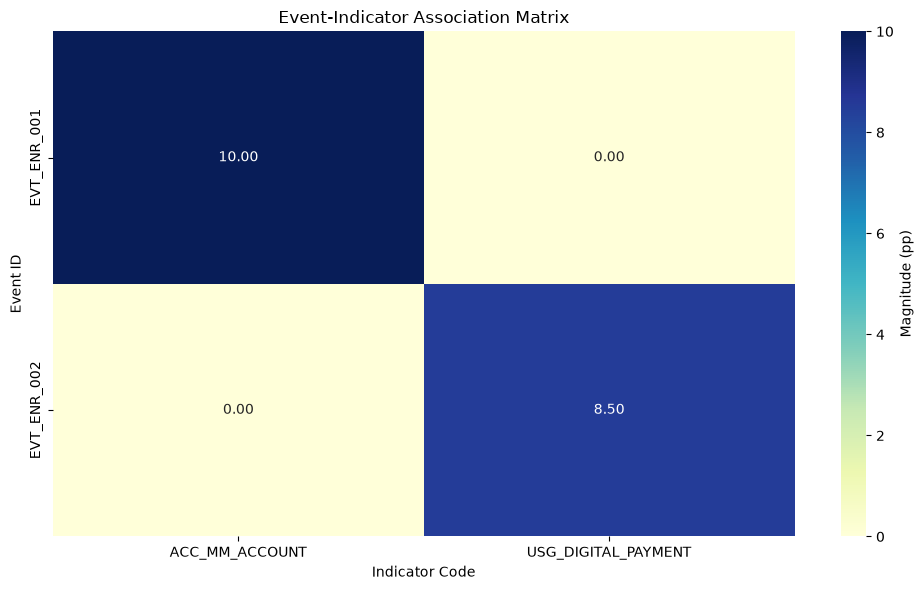

In [20]:
matrix = build_association_matrix(impact_df)
# 1. Print matrix info to inspect dimensions and data types
print("Matrix shape:", matrix.shape)
print("=== EVENT-INDICATOR ASSOCIATION MATRIX (Percentage Points) ===")
display(matrix)

# 2. Plot heatmap safely
if matrix.empty:
    print("Warning: Association matrix is empty. Check if impact_link records exist in your dataset.")
else:
    # Convert all columns to numeric just in case
    numeric_matrix = matrix.apply(pd.to_numeric, errors='coerce').fillna(0.0)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        numeric_matrix, 
        annot=True, 
        cmap="YlGnBu", 
        fmt=".2f", 
        cbar_kws={'label': 'Magnitude (pp)'}
    )
    plt.title("Event-Indicator Association Matrix")
    plt.ylabel("Event ID")
    plt.xlabel("Indicator Code")
    plt.tight_layout()
    plt.savefig("../reports/figures/event_association_matrix.png")
    plt.show()

## 2. Temporal Ramp-Up Function Simulation

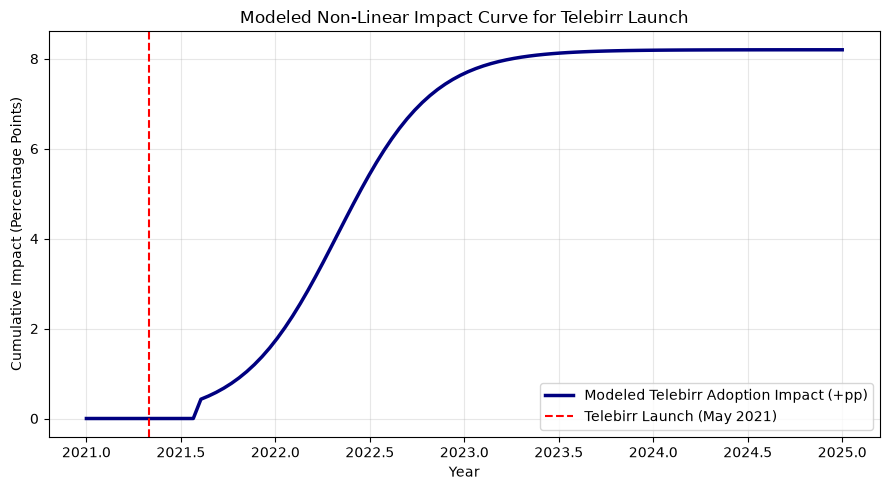

In [21]:
years = np.linspace(2021.0, 2025.0, 100)
telebirr_impact_curve = [
    calculate_temporal_impact(t, t_event=2021.33, magnitude=8.2, lag_months=3.0, ramp_months=18.0)
    for t in years
]

plt.figure(figsize=(9, 5))
plt.plot(years, telebirr_impact_curve, color='navy', lw=2.5, label='Modeled Telebirr Adoption Impact (+pp)')
plt.axvline(2021.33, color='red', linestyle='--', label='Telebirr Launch (May 2021)')
plt.title("Modeled Non-Linear Impact Curve for Telebirr Launch")
plt.xlabel("Year")
plt.ylabel("Cumulative Impact (Percentage Points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/telebirr_temporal_impact.png")
plt.show()

## 3. Historical Model Validation (Telebirr 2021 vs Findex 2024)

In [22]:
validation_results = validate_telebirr_impact()
print("=== HISTORICAL VALIDATION RESULTS ===")
for k, v in validation_results.items():
    print(f"  {k}: {v}")

=== HISTORICAL VALIDATION RESULTS ===
  baseline_2021: 4.7
  observed_2024: 19.4
  predicted_2024: 15.4
  absolute_error_pp: 4.0
  mape_pct: 20.62
